### **Package**

In [22]:
import subprocess
import sys
import os

print(sys.version)

try:
    import pymoo
    print("pymoo is already installed.")
except ImportError:
    print("pymoo is not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymoo"])
print("pymoo installed.")

try:
    import GPy
    print("GPy is already installed.")
except ImportError:
    print("GPy is not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "GPy"])
print("GPy installed.")


import warnings
warnings.filterwarnings("ignore", message=".*load_learner.*pickle.*")

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pymoo is already installed.
pymoo installed.
GPy is already installed.
GPy installed.


In [23]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from pymoo.operators.sampling.lhs import LHS
from pymoo.problems import get_problem
from pymoo.core.problem import Problem
from pymoo.util.ref_dirs import get_reference_directions
import plotly.graph_objects as go


# Optimization algorithm
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.termination import get_termination
from pymoo.core.survival import Survival
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
from pymoo.util.randomized_argsort import randomized_argsort
from pymoo.operators.survival.rank_and_crowding import RankAndCrowding
from pymoo.problems.multi.omnitest import OmniTest

# Surrogate model
import GPy

# Metrics
from pymoo.indicators.hv import HV
from pymoo.indicators.igd_plus import IGDPlus
from sklearn.metrics import mean_squared_error, mean_absolute_error

### **Class and Function**

In [24]:
from pymoo.core.callback import Callback
from IPython.display import clear_output

class EvaluatePreRealCallback(Callback):
    def __init__(self, true_problem, plot_every=1, use_opt=True, dynamic_show=False,
                 prefix="", obj_min=None, obj_max=None, hv_indicator=None):
        super().__init__()
        self.true_problem = true_problem
        self.plot_every = plot_every
        self.use_opt = use_opt
        self.dynamic_show = dynamic_show
        self.prefix = prefix
        self.max_f_so_far = None
        self.obj_min = None if obj_min is None else np.asarray(obj_min, dtype=float)
        self.obj_max = None if obj_max is None else np.asarray(obj_max, dtype=float)
        self.hv_indicator = hv_indicator
        self.records = []

    def notify(self, algorithm):
        gen = algorithm.n_gen

        if gen % self.plot_every != 0:
            return

        pop = algorithm.opt if self.use_opt else algorithm.pop
        X = pop.get("X")
        pre = pop.get("F")
        real = self.true_problem.evaluate(X, return_values_of=["F"])

        hv_sur = None
        hv_real = None
        if self.hv_indicator is not None and self.obj_min is not None and self.obj_max is not None:
            pre_norm = (pre - self.obj_min) / (self.obj_max - self.obj_min)
            real_norm = (real - self.obj_min) / (self.obj_max - self.obj_min)
            hv_sur = float(self.hv_indicator.do(pre_norm))
            hv_real = float(self.hv_indicator.do(real_norm))

        if self.dynamic_show:
            clear_output(wait=True)

        max_pre = np.max(pre, axis=0)
        max_real = np.max(real, axis=0)
        max_f = np.maximum(max_pre, max_real)

        if self.max_f_so_far is None:
            self.max_f_so_far = max_f.copy()
        else:
            self.max_f_so_far = np.maximum(self.max_f_so_far, max_f)

        print(f"[{self.prefix}] Generation {gen}")
        print(f"Max f1: {self.max_f_so_far[0]:.2f}| {self.obj_max[0] * 1.1 :.2f}")
        print(f"Max f2: {self.max_f_so_far[1]:.2f}| {self.obj_max[1] * 1.1 :.2f}")

        if hv_sur is not None and hv_real is not None:
            print(f"HV sur : {hv_sur:.4f}")
            print(f"HV real: {hv_real:.4f}")

        result = evaluate_pre_real(
            pre,
            real,
            title=f"{self.prefix} | Gen {gen}",
            show_plot=True
        )

        self.records.append({
            "gen": gen,
            "X": X.copy(),
            "pre": pre.copy(),
            "real": real.copy(),
            "hv_sur": hv_sur,
            "hv_real": hv_real,
            **result
        })

###### Plot and Metrics

In [25]:
# Plot: 2 Objs and pareto front
def plot_obj_2d(F, xlim=(0, 1), ylim=(0, 1),):
    n_obj = F.shape[1]
    if n_obj == 2:
        nds = NonDominatedSorting()
        front_idx = nds.do(F, only_non_dominated_front=True)

        pareto_F = F[front_idx]
        non_pareto_F = np.delete(F, front_idx, axis=0)

        fig = go.Figure(
            data=go.Scatter(
                x=F[:, 0],
                y=F[:, 1],
                mode='markers',
                name='Objective Values',
                marker=dict(size=6, color='#87CEEB', opacity=0.7)
            )
        )
        fig.add_trace(go.Scatter(
            x=pareto_F[:, 0],
            y=pareto_F[:, 1],
            mode='markers',
            name='Pareto Front',
            marker=dict(size=7, color='#FF7F0E', opacity=0.9, symbol='diamond')
    ))
        fig.update_layout(
            xaxis_title='f1',
            yaxis_title='f2',
            width=600,
            height=600,
            xaxis=dict(range=list(xlim)),
            yaxis=dict(range=list(ylim))
        )
    fig.show()


def mean_std(arr):
    return np.mean(arr), np.std(arr)

In [26]:
def evaluate_pre_real(pre, real, title=None, figsize=(7, 6), point_size=20, show_plot=True):
    pre = np.asarray(pre, dtype=float)
    real = np.asarray(real, dtype=float)

    if pre.ndim != 2 or real.ndim != 2:
        raise ValueError("pre and real must be 2D arrays.")
    if pre.shape[1] != 2 or real.shape[1] != 2:
        raise ValueError("pre and real must have shape (n, 2).")
    if pre.shape[0] != real.shape[0]:
        raise ValueError("pre and real must have the same number of rows.")

    # row-wise Euclidean distance
    distances = np.sqrt(np.sum((pre - real) ** 2, axis=1))

    max_idx = np.argmax(distances)
    min_idx = np.argmin(distances)

    result = {
        "distances": distances,
        "max_distance": distances[max_idx],
        "max_obj_point": pre[max_idx],
        "max_f_real_point": real[max_idx],
        "min_distance": distances[min_idx],
        "min_obj_point": pre[min_idx],
        "min_f_real_point": real[min_idx],
        "mean_distance": np.mean(distances)
    }

    if show_plot:
        fig, ax = plt.subplots(figsize=figsize)

        for i in range(pre.shape[0]):
            ax.annotate(
                '',
                xy=(real[i, 0], real[i, 1]),
                xytext=(pre[i, 0], pre[i, 1]),
                arrowprops=dict(
                    arrowstyle='->',
                    color='green',
                    lw=1.0,
                    alpha=0.8,
                    shrinkA=0,
                    shrinkB=0
                )
            )

        ax.scatter(
            pre[:, 0], pre[:, 1],
            color='#87CEEB',
            s=point_size,
            alpha=0.8,
            label='pre'
        )

        ax.scatter(
            real[:, 0], real[:, 1],
            color='#FF7F0E',
            s=point_size,
            alpha=0.8,
            label='real'
        )

        ax.set_xlabel('F1')
        ax.set_ylabel('F2')
        if title is not None:
            ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

    print(f"Max:  {result['max_distance']:.2f}, sur={result['max_obj_point']}, real={result['max_f_real_point']}")
    print(f"Min:  {result['min_distance']:.2f}, sur={result['min_obj_point']}, real={result['min_f_real_point']}")
    print(f"Mean: {result['mean_distance']:.2f}")
    print("-" * 50)

    return result

###### Class: Surrogate model

In [27]:
# Model: Kriging_Matern
class Kriging_Matern:
    def __init__(self):
        self.model = None

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        dim = X.shape[1]

        kernel = GPy.kern.Matern52(input_dim=dim, ARD=True)
        self.model = GPy.models.GPRegression(X, y, kernel, normalizer=True)
        #self.model.Gaussian_noise.variance = 1e-6
        #self.model.Gaussian_noise.variance.fix()
        self.model.optimize(messages=False)

    def predict(self, X):
        y_mean, y_var = self.model.predict(X, include_likelihood=True)
        y_std = np.sqrt(y_var)
        return y_mean.flatten(), y_std.flatten()

In [28]:
# Model: Kriging_Matern_small_noise
class Kriging_Matern_small_noise:
    def __init__(self):
        self.model = None

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        dim = X.shape[1]

        kernel = GPy.kern.Matern52(input_dim=dim, ARD=True)
        self.model = GPy.models.GPRegression(X, y, kernel, normalizer=True)
        self.model.Gaussian_noise.variance = 1e-6
        self.model.Gaussian_noise.variance.fix()
        self.model.optimize(messages=False)

    def predict(self, X):
        y_mean, y_var = self.model.predict(X, include_likelihood=False)
        y_std = np.sqrt(y_var)
        return y_mean.flatten(), y_std.flatten()

###### Define Problem

In [29]:
# Problem
class Benchmark_Problem(Problem):
    def __init__(self, model_f1, model_f2, n_var, n_obj, xl, xu, problem_name, use_surrogate):

        if 'dtlz' in problem_name:
          self.problem = get_problem(problem_name, n_var=n_var, n_obj=n_obj)
        elif 'omnitest' in problem_name:
          self.problem = OmniTest(n_var=n_var)
        else:
          self.problem = get_problem(problem_name)

        n_constr = self.problem.n_constr if self.problem.has_constraints() else 0

        super().__init__(n_var=n_var, n_obj=n_obj, xl=xl, xu=xu,
                         n_constr=n_constr, model=None,
                         evaluation_model=None)

        self.model_f1 = model_f1
        self.model_f2 = model_f2
        self.use_surrogate = use_surrogate

    def _evaluate(self, X, out, *args, **kwargs):
        if self.use_surrogate == 'Kriging_uncertainty':
          y1_mean, y1_std = self.model_f1.predict(X)
          y2_mean, y2_std = self.model_f2.predict(X)

          y1_mean = y1_mean.reshape(-1, 1)
          y2_mean = y2_mean.reshape(-1, 1)
          y1_std = y1_std.reshape(-1, 1)
          y2_std = y2_std.reshape(-1, 1)

          out["F"] = np.hstack([y1_mean, y2_mean])
          out["std"] = np.hstack([y1_std, y2_std])

          if self.problem.has_constraints():
            out["G"] = self.problem.evaluate(X, return_values_of=["G"])

        else:
          out["F"] = self.problem.evaluate(X, return_values_of=["F"])

###### Class: Survival_standard

In [30]:
class Survival_standard(Survival):

    def __init__(self, nds=None, crowding_func="cd"):
        crowding_func_ = get_crowding_function(crowding_func)
        super().__init__(filter_infeasible=True)
        self.nds = nds if nds is not None else NonDominatedSorting()
        self.crowding_func = crowding_func_


    def _do(self,
            problem,
            pop,
            *args,
            random_state=None,
            n_survive=None,
            **kwargs):

        F = pop.get("F").astype(float, copy=False)

        survivors = []

        fronts = self.nds.do(F, n_stop_if_ranked=n_survive)

        for k, front in enumerate(fronts):

            I = np.arange(len(front))

            if len(survivors) + len(I) > n_survive:
                n_remove = len(survivors) + len(front) - n_survive
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=n_remove
                    )

                I = randomized_argsort(crowding_of_front, order='descending', method='numpy', random_state=random_state)
                I = I[:-n_remove]

            else:
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=0
                    )

            for j, i in enumerate(front):
                pop[i].set("rank", k)
                pop[i].set("crowding", crowding_of_front[j])
            survivors.extend(front[I])

        return pop[survivors]


###### Class: Survival_dual_ranking

In [31]:
class Survival_dual_ranking(Survival):

    def __init__(self, nds=None, crowding_func="cd", alpha_f1=1, alpha_f2=1):
        crowding_func_ = get_crowding_function(crowding_func)
        super().__init__(filter_infeasible=True)
        self.nds = nds if nds is not None else NonDominatedSorting()
        self.crowding_func = crowding_func_
        self.alpha_f1 = alpha_f1
        self.alpha_f2 = alpha_f2


    def _do(self,problem,pop,*args,random_state=None,n_survive=None,**kwargs):
        F = pop.get("F").astype(float, copy=False)
        F_std = pop.get("std").astype(float, copy=False)

        #============= F_upper =====================
        alphas = np.array([self.alpha_f1, self.alpha_f2])
        F_upper = F + alphas * F_std
        F_hybrid = np.concatenate([F, F_upper], axis=1)
        #===========================================

        # ====== NonDominatedSorting ============
        fronts_hybrid = NonDominatedSorting().do(F_hybrid)
        #==========================================

        survivors = []
        for k, front in enumerate(fronts_hybrid):

            I = np.arange(len(front))

            if len(survivors) + len(I) > n_survive:
                n_remove = len(survivors) + len(front) - n_survive
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=n_remove
                    )

                I = randomized_argsort(crowding_of_front, order='descending', method='numpy', random_state=random_state)
                I = I[:-n_remove]

            else:
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=0
                    )

            for j, i in enumerate(front):
                pop[i].set("rank", k)
                pop[i].set("crowding", crowding_of_front[j])
            survivors.extend(front[I])

        return pop[survivors]


### **Main**

###### 1. Initial settings



In [32]:
# Initial settings
# Problem: dtlz1-7, omnitest, bnh, truss2d, welded_beam
problem_name = 'dtlz1'

if 'dtlz' in problem_name:
  n_var = 10
  n_obj = 2
  problem = get_problem(problem_name, n_var=n_var, n_obj=n_obj)

elif 'omnitest' in problem_name:
  n_var = 2
  n_obj = 2
  problem = OmniTest(n_var=n_var)

else:
  problem = get_problem(problem_name)
  n_var = problem.n_var
  n_obj = problem.n_obj

print(f"Problem name: {problem_name}")
print(f"Cons: {problem.n_constr}")
print(f"Var: {n_var}")
print(f"Obj: {n_obj}")

# n_gen, pop_size
n_gen = 100
pop_size = 100
np.set_printoptions(precision=4, suppress=True)

# Data
# LHS sampling with seed 42
np.random.seed(42)
sample_size = 11*n_var-1
sampling = LHS()

X_train = sampling(problem, sample_size, seed=42).get("X")
y_train = problem.evaluate(X_train, return_values_of=["F"])
y_train_f1 = y_train[:, 0]
y_train_f2 = y_train[:, 1]
print('\nSampling X_train shape: ', X_train.shape)

X_val = sampling(problem, 100, seed=42).get("X")
y_val = problem.evaluate(X_val, return_values_of=["F"])
print('y_val shape: ', y_val.shape)

X_test = sampling(problem, 100, seed=1).get("X")
y_test = problem.evaluate(X_test, return_values_of=["F"])
print('y_test shape: ', y_test.shape)


# Metrics: HV
if problem_name == 'dtlz1':
  obj_min = np.array([0,0])
  obj_max = np.array([700,700])

if problem_name == 'dtlz2':
  obj_min = np.array([0,0])
  obj_max = np.array([2.78,2.93])

if problem_name == 'dtlz3':
  obj_min = np.array([0,0])
  obj_max = np.array([1605.54,1670.48])

if problem_name == 'dtlz4':
  obj_min = np.array([0,0])
  obj_max = np.array([2.83,2.78])

if problem_name == 'dtlz5':
  obj_min = np.array([0,0])
  obj_max = np.array([2.61,2.70])

if problem_name == 'dtlz6':
  obj_min = np.array([0,0])
  obj_max = np.array([9.78,9.78])

if problem_name == 'dtlz7':
  obj_min = np.array([0,0])
  obj_max = np.array([1.10,33.43])

if problem_name == 'omnitest':
  obj_min = np.array([-2,-2])
  obj_max = np.array([2.40,2.40])

if problem_name == 'bnh':
  obj_min = np.array([0,5])
  obj_max = np.array([140,50])

if problem_name == 'truss2d':
  obj_min = np.array([0,0])
  obj_max = np.array([0.1,1e5])

if problem_name == 'welded_beam':
  obj_min = np.array([0,0])
  obj_max = np.array([160,0.20])

ref_point = np.array([1.1,1.1])
hv = HV(ref_point=ref_point)
print('\nMin-Max normalization -> Min: ', obj_min)
print('Min-Max normalization -> Max: ', obj_max)
print('HV Reference points: ', ref_point)

# Metrics: IGD+
n_points = 200
if problem_name == 'dtlz5':
    X_opt = np.full((n_points, n_var), 0.5)
    X_opt[:, 0] = np.linspace(0, 1, n_points)
    pf = problem.evaluate(X_opt)

elif problem_name == 'dtlz6':
    X_opt = np.zeros((n_points, n_var))
    X_opt[:, 0] = np.linspace(0, 1, n_points)
    pf = problem.evaluate(X_opt)

elif problem_name == 'dtlz7':
    X_opt = np.zeros((n_points, n_var))
    X_opt[:, :n_obj-1] = np.linspace(0, 1, n_points).reshape(-1, 1)
    pf = problem.evaluate(X_opt)
else:
    pf = problem.pareto_front()
igd_plus = IGDPlus(pf)

Problem name: dtlz1
Cons: 0
Var: 10
Obj: 2

Sampling X_train shape:  (109, 10)
y_val shape:  (100, 2)
y_test shape:  (100, 2)

Min-Max normalization -> Min:  [0 0]
Min-Max normalization -> Max:  [700 700]
HV Reference points:  [1.1 1.1]


###### 2. Surrogate model training

In [33]:
# Kriging
def model(X_train, y_train_f1, y_train_f2, X_test, model_name):
    if model_name == 'Kriging_Matern':
        model_kriging_f1 = Kriging_Matern()
        model_kriging_f2 = Kriging_Matern()
    elif model_name == 'Kriging_Matern_small_noise':
        model_kriging_f1 = Kriging_Matern_small_noise()
        model_kriging_f2 = Kriging_Matern_small_noise()
    print('model_name: ', model_name)

    model_kriging_f1.fit(X_train, y_train_f1)
    model_kriging_f2.fit(X_train, y_train_f2)

    # Predict
    mean_f1, std_f1 = model_kriging_f1.predict(X_test)
    mean_f2, std_f2 = model_kriging_f2.predict(X_test)
    pred_mean = np.stack([mean_f1, mean_f2], axis=1)
    pred_std = np.stack([std_f1, std_f2], axis=1)

    # Metrics
    mse_kriging = mean_squared_error(y_test, pred_mean)
    print(f"Kriging(Matern) MSE: {mse_kriging:.2e}\n")

    print("f1 lengthscale:", model_kriging_f1.model.kern.lengthscale.values)
    print("f1 kernel variance:", model_kriging_f1.model.kern.variance.values)
    print("f1 noise:", model_kriging_f1.model.Gaussian_noise.variance.values)
    print("f2 lengthscale:", model_kriging_f2.model.kern.lengthscale.values)
    print("f2 kernel variance:", model_kriging_f2.model.kern.variance.values)
    print("f2 noise:", model_kriging_f2.model.Gaussian_noise.variance.values)

    print('pred_mean\n', pred_mean[0:5])
    print('pred_std\n', pred_std[0:5])
    print('Max pred_std\n', np.max(pred_std, axis=0))

    return model_kriging_f1, model_kriging_f2

In [34]:
model_kriging_f1, model_kriging_f2 = model(X_train, y_train_f1, y_train_f2, X_test, 'Kriging_Matern')

model_name:  Kriging_Matern


/usr/local/lib/python3.12/dist-packages/GPy/kern/src/stationary.py:137: RuntimeWarning:

overflow encountered in square

/usr/local/lib/python3.12/dist-packages/GPy/kern/src/stationary.py:138: RuntimeWarning:

invalid value encountered in add



Kriging(Matern) MSE: 4.81e+03

f1 lengthscale: [  2.9056  32.222  188.4616  51.6894  38.3763 203.5573  92.0137 138.2754
 213.6507 188.3865]
f1 kernel variance: [18.296]
f1 noise: [0.1873]
f2 lengthscale: [    0.7804 18673.5827     2.5937  8221.6106 27584.3572 24242.6981
     7.6323 37104.7887 42187.2221    10.5077]
f2 kernel variance: [2.3736]
f2 noise: [0.1029]
pred_mean
 [[322.4031 161.8273]
 [148.06   346.0587]
 [ 82.0872 433.7016]
 [ 22.1692 536.8068]
 [102.2976 378.0641]]
pred_std
 [[65.8131 53.6122]
 [65.6815 53.3786]
 [66.0327 54.613 ]
 [67.0775 55.3159]
 [65.8426 53.158 ]]
Max pred_std
 [67.7532 58.9312]


In [35]:
_,_ = model(X_train, y_train_f1, y_train_f2, X_test, 'Kriging_Matern_small_noise')

model_name:  Kriging_Matern_small_noise
Kriging(Matern) MSE: 7.65e+03

f1 lengthscale: [   0.2337    5.391  1951.4923    2.4296    1.4596    0.6883 4062.6595
    0.2984    1.8763    2.6636]
f1 kernel variance: [0.9409]
f1 noise: [0.]
f2 lengthscale: [   0.1197 5881.7496    1.5596    0.9708 4094.266     1.6331    1.7885
 5617.3656 6528.6293    0.4641]
f2 kernel variance: [0.5946]
f2 noise: [0.]
pred_mean
 [[205.8817  83.6265]
 [129.0803 230.2747]
 [ 96.9142 391.3275]
 [ 40.1613 524.1122]
 [ 94.159  315.1176]]
pred_std
 [[54.641  45.9539]
 [58.7048 45.1926]
 [56.4713 55.3842]
 [79.8305 42.5085]
 [48.9511 54.8144]]
Max pred_std
 [88.0782 69.8782]


###### 2.1 CICP & Z score

Coverage
k=1.645: per_dim=[92. 84.]%, overall=88.0%


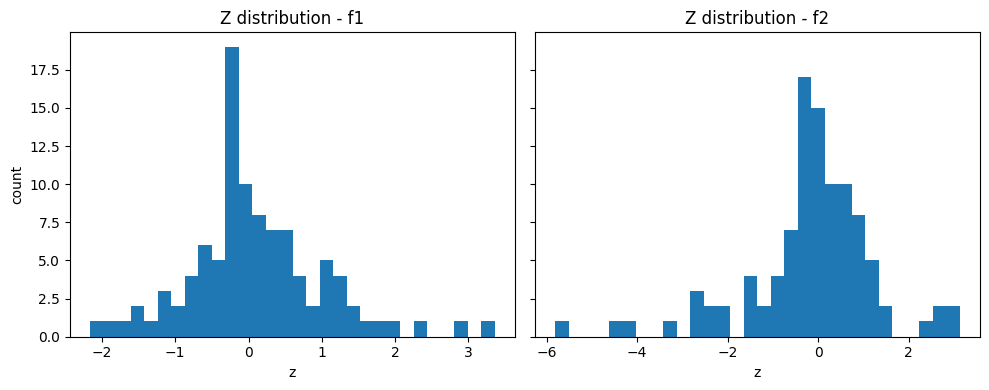

In [36]:
mean_f1, std_f1 = model_kriging_f1.predict(X_test)
mean_f2, std_f2 = model_kriging_f2.predict(X_test)
pred_mean = np.stack([mean_f1, mean_f2], axis=1)
pred_std = np.stack([std_f1, std_f2], axis=1)

###### CICP
"""
Interval    Coverage
±1.282σ      80.00%
±1.645σ      90.00%
±1.960σ      95.00%
"""
def coverage(y_test, pred_mean, pred_std, k=1.0):
    err = np.abs(y_test - pred_mean)
    inside = err <= k * pred_std
    per_dim = inside.mean(axis=0)
    overall = inside.mean()
    return per_dim, overall
print('Coverage')
for k in [1.645]:
    per_dim, overall = coverage(y_test, pred_mean, pred_std, k=k)
    print(f"k={k}: per_dim={per_dim*100}%, overall={overall*100:.1f}%")


###### Z score
z = (y_test - pred_mean) / pred_std
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i in range(2):
    axes[i].hist(z[:, i], bins=30)
    axes[i].set_title(f"Z distribution - f{i+1}")
    axes[i].set_xlabel("z")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

###### 2.2 find_alpha

In [37]:
def find_alpha(X_val, y_val,
               model_kriging,target_coverage,
               alpha_max=50, alpha_step=0.01):
  mean, std = model_kriging.predict(X_val)

  alpha = 0
  while alpha < alpha_max:
      f_upper = mean + alpha * std
      coverage = np.mean(y_val <= f_upper)

      if coverage >= target_coverage:
            best_alpha = alpha
            print(f"coverage={coverage*100:.2f}%")
            break

      alpha += alpha_step

  return best_alpha


alpha_c80_f1 = find_alpha(X_val, y_val[:,0], model_kriging_f1, target_coverage=0.8)
alpha_c80_f2 = find_alpha(X_val, y_val[:,1], model_kriging_f2, target_coverage=0.8)
print(f"alpha_c80_f1={alpha_c80_f1:.2f}, alpha_c80_f2={alpha_c80_f2:.2f}")
F_upper_c80 = np.stack([mean_f1 + alpha_c80_f1 * std_f1,
                        mean_f2 + alpha_c80_f2 * std_f2], axis=1)
print('F_upper_c80\n', F_upper_c80[0:5],'\n')

alpha_c90_f1 = find_alpha(X_val, y_val[:,0], model_kriging_f1, target_coverage=0.9)
alpha_c90_f2 = find_alpha(X_val, y_val[:,1], model_kriging_f2, target_coverage=0.9)
print(f"alpha_c90_f1={alpha_c90_f1:.2f}, alpha_c90_f2={alpha_c90_f2:.2f}")
F_upper_c90 = np.stack([mean_f1 + alpha_c90_f1 * std_f1,
                        mean_f2 + alpha_c90_f2 * std_f2], axis=1)
print('F_upper_c90\n', F_upper_c90[0:5],'\n')

alpha_c95_f1 = find_alpha(X_val, y_val[:,0], model_kriging_f1, target_coverage=0.95)
alpha_c95_f2 = find_alpha(X_val, y_val[:,1], model_kriging_f2, target_coverage=0.95)
print(f"alpha_c95_f1={alpha_c95_f1:.2f}, alpha_c95_f2={alpha_c95_f2:.2f}")

F_upper_c95 = np.stack([mean_f1 + alpha_c95_f1 * std_f1,
                        mean_f2 + alpha_c95_f2 * std_f2], axis=1)
print('F_upper_c95\n', F_upper_c95[0:5],'\n')

coverage=80.00%
coverage=80.00%
alpha_c80_f1=0.53, alpha_c80_f2=0.58
F_upper_c80
 [[357.284  192.9224]
 [182.8712 377.0184]
 [117.0846 465.3772]
 [ 57.7203 568.8901]
 [137.1942 408.8957]] 

coverage=90.00%
coverage=90.00%
alpha_c90_f1=1.25, alpha_c90_f2=1.14
F_upper_c90
 [[404.6695 222.9452]
 [230.1619 406.9104]
 [164.6281 495.9605]
 [106.016  599.867 ]
 [184.6009 438.6642]] 

coverage=95.00%
coverage=95.00%
alpha_c95_f1=1.77, alpha_c95_f2=1.53
F_upper_c95
 [[438.8923 243.854 ]
 [264.3163 427.7281]
 [198.9651 517.2596]
 [140.8963 621.4402]
 [218.839  459.3959]] 



###### 3. Optimization

In [17]:
# Algorithm
algorithm = NSGA2(
    pop_size=100,
    crossover = SBX(prob=1.0, eta=20),
    mutation = PM(prob=1/n_var, eta=20),
    survival=Survival_standard(),     ### change
    eliminate_duplicates=True)

mse_list, igd_list, hv_surrogate_list, hv_real_list,  = [], [], [], []

for seed in range(1, 2):
    benchmark_problem_kriging = Benchmark_Problem(
        model_f1=model_kriging_f1,
        model_f2=model_kriging_f2,
        n_var=n_var,
        n_obj=n_obj,
        xl=problem.xl,
        xu=problem.xu,
        problem_name=problem_name,
        use_surrogate='Kriging_uncertainty')

    # Optimization
    start_time = time.time()

    callback_standard = EvaluatePreRealCallback(
        true_problem=problem,
        plot_every=1,
        use_opt=True,
        dynamic_show=False,
        prefix="NSGA2-standard",
        obj_min=obj_min,
        obj_max=obj_max,
        hv_indicator=hv
    )

    res = minimize(
        benchmark_problem_kriging,
        algorithm,
        termination=get_termination("n_gen", n_gen),
        seed=seed,
        save_history=True,
        verbose=False,
        callback=callback_standard
    )
    end_time = time.time()

    solution = res.history[-1].opt.get("X")
    obj = res.history[-1].opt.get("F")
    f_real = problem.evaluate(solution, return_values_of=["F"])

    # MSE
    mse = mean_squared_error(f_real, obj)
    mse_list.append(mse)
    # IGD+
    igd_plus_real = float(igd_plus(f_real))
    igd_list.append(igd_plus_real)
    # HV
    f_real_normalization = (f_real - obj_min) / (obj_max - obj_min)
    obj_normalization = (obj - obj_min) / (obj_max - obj_min)
    hv_real = float(hv.do(f_real_normalization))
    hv_surrogate = float(hv.do(obj_normalization))
    hv_real_list.append(hv_real)
    hv_surrogate_list.append(hv_surrogate)

    max_obj = np.max(obj, axis=0)
    max_obj_real = np.max(f_real, axis=0)
    print(f"Seed {seed} | Time: {end_time - start_time:.2f}s | "
          f"MSE: {mse:.2e} | "
          f"igd+: {igd_plus_real:.2e} | "
          f"Sur HV: {hv_surrogate:.2f} | "
          f"Real HV: {hv_real:.2f} | "
          f"Max f_real: {max_obj_real}")

plot_obj_2d(obj,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))

Output hidden; open in https://colab.research.google.com to view.

In [18]:
# mean_mse, std_mse = mean_std(mse_list)
# mean_igd, std_igd = mean_std(igd_list)
# mean_hv_real, std_hv_real = mean_std(hv_real_list)
# mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

# print('Problem name: ', problem_name)
# print("\n=== Kriging ===")

# print(f"MSE: Mean = {mean_mse:.2e}, Std = {std_mse:.2e}")
# print(f"IGD+: Mean = {mean_igd:.2e}, Std = {std_igd:.2e}")
# print(f"Sur HV: Mean = {mean_hv_surrogate:.2f}, Std = {std_hv_surrogate:.2f}")
# print(f"Real HV: Mean = {mean_hv_real:.2f}, Std = {std_hv_real:.2f}")

###### 3. Optimization Kriging (Matern) + dual-ranking (c=0.90)

In [19]:
# Algorithm
algorithm = NSGA2(
    pop_size=100,
    crossover = SBX(prob=1.0, eta=20),
    mutation = PM(prob=1/n_var, eta=20),
    survival=Survival_dual_ranking(alpha_f1=alpha_c90_f1,
                                   alpha_f2=alpha_c90_f2),     ### change
    eliminate_duplicates=True)

mse_list, igd_list, hv_surrogate_list, hv_real_list,  = [], [], [], []

for seed in range(1, 2):
    benchmark_problem = Benchmark_Problem(
        model_f1=model_kriging_f1,   ### change
        model_f2=model_kriging_f2,   ### change
        n_var=n_var,
        n_obj=n_obj,
        xl=problem.xl,
        xu=problem.xu,
        problem_name=problem_name,
        use_surrogate='Kriging_uncertainty')   ### change

    # Optimization
    start_time = time.time()

    res = minimize(
        benchmark_problem,
        algorithm,
        termination = get_termination("n_gen", n_gen),
        seed=seed,
        save_history=True,
        verbose=False)

    end_time = time.time()

    solution_c90 = res.history[-1].opt.get("X")
    obj_c90 = res.history[-1].opt.get("F")
    f_real_c90 = problem.evaluate(solution_c90, return_values_of=["F"])

    # MSE
    mse = mean_squared_error(f_real_c90, obj_c90)
    mse_list.append(mse)

    # IGD+
    igd_plus_real = float(igd_plus(f_real_c90))
    igd_list.append(igd_plus_real)

    # HV
    f_real_normalization = (f_real_c90 - obj_min) / (obj_max - obj_min)
    obj_normalization = (obj_c90 - obj_min) / (obj_max - obj_min)
    hv_real = float(hv.do(f_real_normalization))
    hv_surrogate = float(hv.do(obj_normalization))
    hv_real_list.append(hv_real)
    hv_surrogate_list.append(hv_surrogate)

    max_obj = np.max(obj_c90, axis=0)
    max_obj_real = np.max(f_real_c90, axis=0)

    print(f"Seed {seed} | Time: {end_time - start_time:.2f}s | "
          f"MSE: {mse:.2e} | "
          f"igd+: {igd_plus_real:.2e} | "
          f"Sur HV: {hv_surrogate:.2f} | "
          f"Real HV: {hv_real:.2f} | "
          f"Max f_real: {max_obj_real}")

plot_obj_2d(obj_c90,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))

plot_obj_2d(f_real_c90,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))

Seed 1 | Time: 7.25s | MSE: 1.05e+04 | igd+: 1.20e+02 | Sur HV: 0.91 | Real HV: 1.14 | Max f_real: [452.7675 330.6293]


In [20]:
# mean_mse, std_mse = mean_std(mse_list)
# mean_igd, std_igd = mean_std(igd_list)
# mean_hv_real, std_hv_real = mean_std(hv_real_list)
# mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

# print('Problem name: ', problem_name)
# print("\n=== Kriging + dual-ranking + alpha_c90 ===")

# print(f"MSE: Mean = {mean_mse:.2e}, Std = {std_mse:.2e}")
# print(f"IGD+: Mean = {mean_igd:.2e}, Std = {std_igd:.2e}")
# print(f"Sur HV: Mean = {mean_hv_surrogate:.2f}, Std = {std_hv_surrogate:.2f}")
# print(f"Real HV: Mean = {mean_hv_real:.2f}, Std = {std_hv_real:.2f}")



###### Test

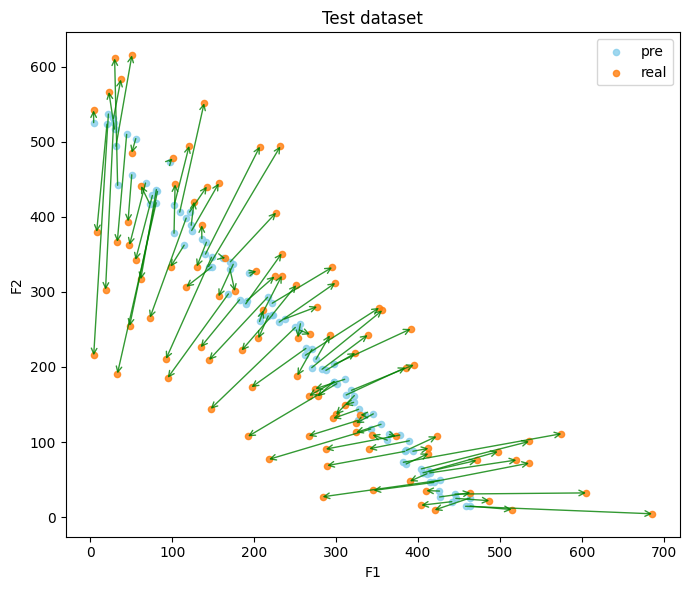

Max:  321.92, sur=[ 22.1692 536.8068], real=[  4.2316 215.3907]
Min:  2.26, sur=[162.3708 345.4809], real=[164.5678 344.9499]
Mean: 77.64
--------------------------------------------------


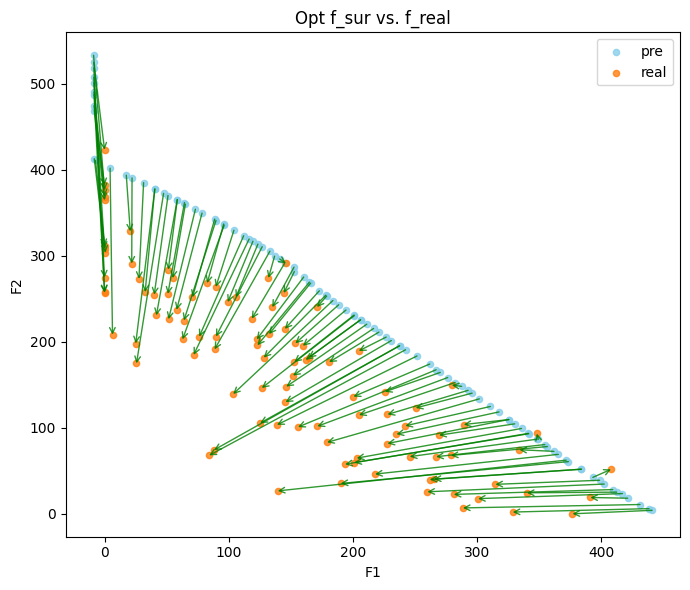

Max:  260.92, sur=[ -8.6701 518.4809], real=[  0.0135 257.7064]
Min:  6.99, sur=[349.4697  86.6271], real=[348.2722  93.5146]
Mean: 102.84
--------------------------------------------------


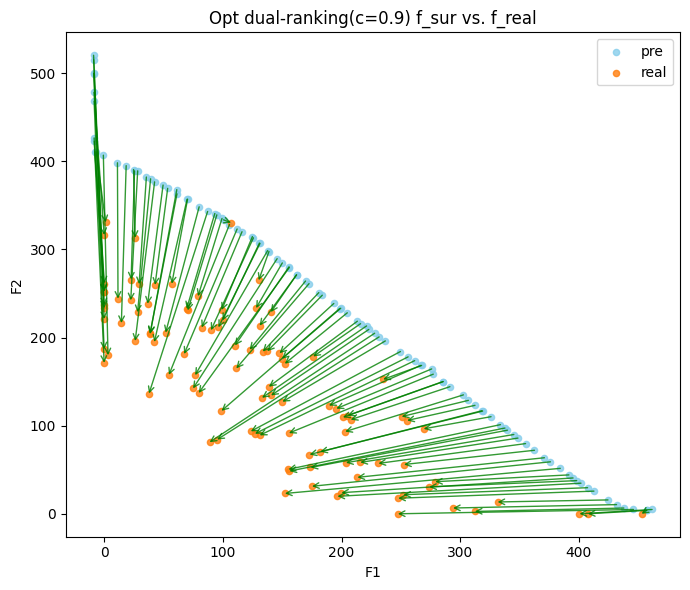

Max:  299.51, sur=[ -8.9066 520.2871], real=[  0.0093 220.9105]
Min:  5.80, sur=[457.1271   3.845 ], real=[452.7675   0.0211]
Mean: 132.69
--------------------------------------------------


In [21]:
result1 = evaluate_pre_real(pred_mean, y_test, title="Test dataset")
result2 = evaluate_pre_real(obj, f_real, title="Opt f_sur vs. f_real")
result3 = evaluate_pre_real(obj_c90, f_real_c90, title="Opt dual-ranking(c=0.9) f_sur vs. f_real")